
--- TABELA DE RESULTADOS DO EXPERIMENTO (ETHERNET) ---
 Hosts  Vazão_Shared (%)  Taxa_Colisao (%)  Vazão_Switched (%)
     1             14.80              0.00                15.0
     2             26.55              2.55                30.0
     3             33.65              5.80                45.0
     4             35.25             11.00                60.0
     5             40.00             16.20                75.0
     6             37.90             23.80                90.0
     7             41.15             27.65               100.0
     8             38.60             32.80               100.0
     9             37.15             39.80               100.0
    10             34.15             45.45               100.0
    11             31.85             51.90               100.0
    12             30.95             55.40               100.0
    13             26.50             60.95               100.0
    14             24.55             64.90               100.0

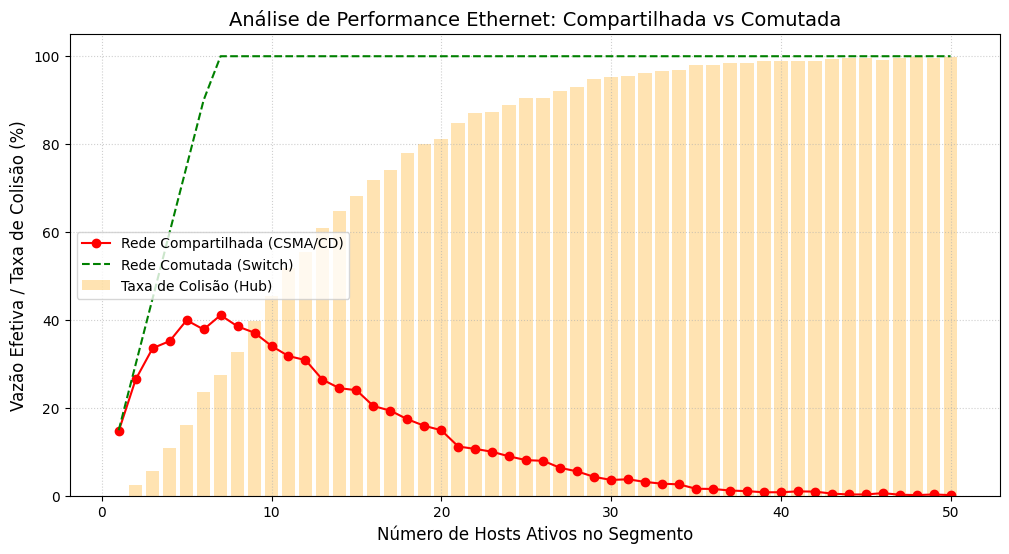

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def simulate_ethernet_performance(max_hosts=50, slots=1000, p_transmit=0.1):
    """
    Simula o comportamento de uma rede Ethernet sob o protocolo CSMA/CD.
    Compara uma rede compartilhada (Hub) com uma rede comutada (Switch).
    """
    results = []

    for n_hosts in range(1, max_hosts + 1):
        # Simulação de tentativas de transmissão (Matriz: Hosts x Slots)
        # 1 representa tentativa de envio, 0 representa ociosidade
        attempts = np.random.choice([0, 1], size=(n_hosts, slots), p=[1-p_transmit, p_transmit])

        # Soma de tentativas por slot
        host_attempts_per_slot = attempts.sum(axis=0)

        # Métricas para Rede Compartilhada (Shared Ethernet / Hub)
        success_slots = np.count_nonzero(host_attempts_per_slot == 1)
        collision_slots = np.count_nonzero(host_attempts_per_slot > 1)
        idle_slots = np.count_nonzero(host_attempts_per_slot == 0)

        throughput_shared = (success_slots / slots) * 100
        collision_rate = (collision_slots / slots) * 100

        # Métricas para Rede Comutada (Switched Ethernet / Switch)
        # Em teoria, no switch cada porta é um domínio de colisão,
        # a vazão é a soma das demandas individuais (limitada a 100% da banda agregada)
        throughput_switched = min((n_hosts * p_transmit * 100), 100.0)

        results.append({
            "Hosts": n_hosts,
            "Vazão_Shared (%)": round(throughput_shared, 2),
            "Taxa_Colisao (%)": round(collision_rate, 2),
            "Vazão_Switched (%)": round(throughput_switched, 2)
        })

    return pd.DataFrame(results)

def generate_report(df):
    # Exibir Tabela Formatada
    print("\n--- TABELA DE RESULTADOS DO EXPERIMENTO (ETHERNET) ---")
    print(df.head(15).to_string(index=False))
    print("...")

    # Gerar Gráfico Comparativo
    plt.figure(figsize=(12, 6))
    plt.plot(df["Hosts"], df["Vazão_Shared (%)"], label="Rede Compartilhada (CSMA/CD)", marker='o', color='red')
    plt.plot(df["Hosts"], df["Vazão_Switched (%)"], label="Rede Comutada (Switch)", linestyle='--', color='green')
    plt.bar(df["Hosts"], df["Taxa_Colisao (%)"], alpha=0.3, label="Taxa de Colisão (Hub)", color='orange')

    plt.title("Análise de Performance Ethernet: Compartilhada vs Comutada", fontsize=14)
    plt.xlabel("Número de Hosts Ativos no Segmento", fontsize=12)
    plt.ylabel("Vazão Efetiva / Taxa de Colisão (%)", fontsize=12)
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.6)

    # Salvar para o Artigo
    plt.savefig('grafico.png', dpi=300)
    print("\n[SUCESSO] Gráfico salvo como 'grafico.png' para o artigo.")
    plt.show()

# Execução do Experimento
if __name__ == "__main__":
    # Parametrizando: 50 hosts, 2000 slots de tempo, 15% de chance de cada host querer transmitir
    data_results = simulate_ethernet_performance(max_hosts=50, slots=2000, p_transmit=0.15)
    generate_report(data_results)